In [18]:
#Boilerplate
from pathlib import Path
#General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Analysis module
import evaluation_tools.inc_learn_tests as st

In [19]:

#Here's what we're testing
results = {'logistic': pd.DataFrame, 'svm':pd.DataFrame, 'xgboost':pd.DataFrame, 'knn': pd.DataFrame, 'naive_bayes':pd.DataFrame}

In [20]:
def read_and_append(file:Path, accumulation_list:list):
    df = pd.read_csv(file, index_col=0)
    acc = df.loc['accuracy'].iloc[0]
    accumulation_list.append(acc)
    return accumulation_list

def inc_base_reader(num_batches:int, result_dict:dict, num_tests:int):
    for clf, _ in result_dict.items():
        results_dir = Path.cwd() / 'results' / 'big_init_chunk_ss' / f"{clf}"
        inc_test_results = []
        inc_train_results = []
        baseline_results = []
        for j in range(num_tests):
            for i in range(num_batches):
                inc_test_results = read_and_append(results_dir / f"{clf}_inc_test{j}_batch{i}_test_accuracy.csv", inc_test_results)
                inc_train_results = read_and_append(results_dir / f"{clf}_inc_test{j}_batch{i}_train_accuracy.csv", inc_train_results)
                baseline_results = read_and_append(results_dir / f"{clf}_base_test{j}_batch{i}_test_accuracy.csv", baseline_results)
            
        inc_test_df = pd.DataFrame(inc_test_results, columns=[f"{clf}_inc_test_accuracy"])
        inc_train_df = pd.DataFrame(inc_train_results, columns=[f"{clf}_inc_train_accuracy"])
        base_df = pd.DataFrame(baseline_results, columns=[f"{clf}_baseline_test_accuracy"])
        results = pd.concat([inc_test_df, inc_train_df, base_df], axis=1)
        
        result_dict[clf] = results
    return result_dict



In [21]:
num_tests = 100
results = inc_base_reader(5, results, num_tests)

In [22]:
# results['logistic']

In [23]:
full_results = pd.concat(results, axis=1).droplevel(level=0, axis=1)

In [24]:
#Setup the variables
# This is where I would test for Normal Distributions
basics = st.TestVariables(results=full_results, num_test=num_tests)
rope_interval = [-0.01, 0.01]
means_dict = {}
vars_dict = {}
for col in basics.model_scores.transpose().columns:
    m, v = st.get_mean_var(basics.model_scores.transpose()[col].to_numpy(), 5, num_tests)
    means_dict[col] = m
    vars_dict[col] = v

mean_model_scores = pd.DataFrame(means_dict)
var_model_scores = pd.DataFrame(vars_dict)

### Proof of Point

### Pairwise Frequentist

In [25]:
pairwise_comp_df = st.pairwise_freq(model_scores=basics.model_scores, num_tests=num_tests, num_batches=basics.num_batch, pairwise_comp_df=None)

### Pairwise Bayesian

In [26]:
# basics.model_scores

In [27]:
pairwise_comp_df = st.pairwise_bayesian(model_scores=basics.model_scores, rope_interval=rope_interval, num_tests=num_tests, num_batches=basics.num_batch, h=1, pairwise_comp_df=pairwise_comp_df)

In [ ]:
# inc_test = [f"{key}_inc_test_accuracy" for key in results.keys()]
# int_train = [f"{key}_inc_train_accuracy" for key in results.keys()]
# baseline = [f"{key}_baseline_test_accuracy" for key in results.keys()]

In [83]:
#mean_model_scores df masks
#Model self comparison masks
mean_logistic_comp = [col for col in mean_model_scores.columns if col.startswith('logistic')]
mean_naive_bayes_comp = [col for col in mean_model_scores.columns if col.startswith('naive_bayes')]
mean_linear_comp = [col for col in mean_model_scores.columns if col.startswith('svm')]
mean_xgboost_comp = [col for col in mean_model_scores.columns if col.startswith('xgboost')]
mean_k_means_comp = [col for col in mean_model_scores.columns if col.startswith('knn')]

#Incremental model comparison masks
mean_inc_test_comp = [col for col in mean_model_scores.columns if 'inc_test' in col]
mean_inc_test_comp_lknn = [col for col in mean_model_scores.columns if 'knn' not in col if'inc_test' in col]

#Baseline model comparison masks
mean_base_test_comp = [col for col in mean_model_scores.columns if 'baseline_test' in col]
mean_base_test_comp_lknn = [col for col in mean_model_scores.columns if 'knn' not in col if'baseline_test' in col]

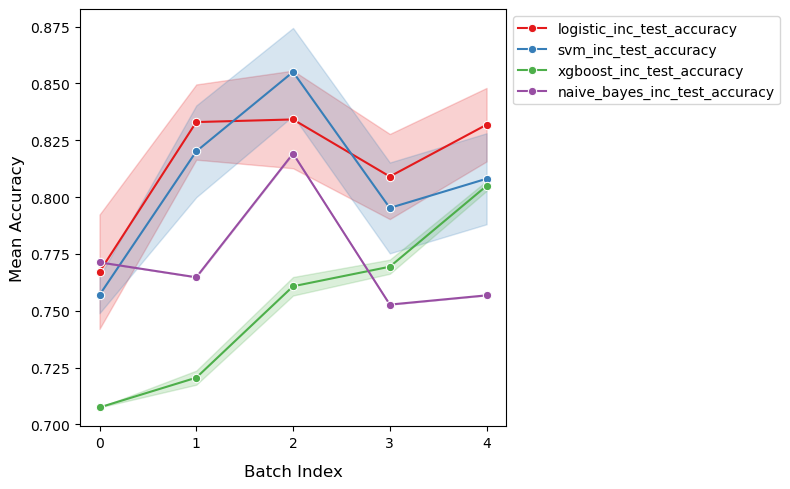

In [86]:

plot_df = mean_model_scores.loc[:,mean_inc_test_comp_lknn]

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Set1", n_colors=len(plot_df.columns))

for i, col in enumerate(plot_df.columns):
    x = plot_df.index
    mean = plot_df[col]
    std = np.sqrt(var_model_scores[col])  # Standard deviation

    # Draw main line
    sns.lineplot(
        x=x,
        y=mean,
        label=col,
        color=colors[i],
        marker="o",
        ax=ax,
    )
    # Add shaded error band (mean ± std)
    ax.fill_between(x, mean - std, mean + std, color=colors[i], alpha=0.2)

ax.set_xticks(plot_df.index)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("Batch Index", size=12, labelpad=10)
ax.set_ylabel("Mean Accuracy", size=12)

plt.tight_layout()
plt.show()

### Interpretation Notes
 - Null Hypothesis is that the two models have the same loss. 
 - Loss Differential (d)=Model 1 Error−Model 2 Error. So a negitive t_stat means that model 2 has higher loss than model 1. 

In [ ]:
#pairwise df masks
#Model self comparison masks
logistic_comp = (pairwise_comp_df['model_1'].str.startswith('logistic')) & (pairwise_comp_df['model_2'].str.startswith('logistic'))
naive_bayes_comp = (pairwise_comp_df['model_1'].str.startswith('naive_bayes')) & (pairwise_comp_df['model_2'].str.startswith('naive_bayes'))
linear_comp = (pairwise_comp_df['model_1'].str.startswith('svm')) & (pairwise_comp_df['model_2'].str.startswith('svm'))
xgboost_comp = (pairwise_comp_df['model_1'].str.startswith('xgboost')) & (pairwise_comp_df['model_2'].str.startswith('xgboost'))
k_means_comp = (pairwise_comp_df['model_1'].str.startswith('knn')) & (pairwise_comp_df['model_2'].str.startswith('knn'))

#Test model comparison masks
inc_test_comp = (pairwise_comp_df['model_1'].str.contains('inc_test')) & (pairwise_comp_df['model_2'].str.contains('inc_test'))

In [65]:

# pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pairwise_comp_df.sort_values(['model_1', 'model_2'], ascending=True).dropna().loc[inc_test_comp]#.tail(30)#.loc[naive_bayes]

,model_1,model_2,t_stat,p_val,worse_prob,better_prob,rope_prob
92,knn_inc_test_accuracy,naive_bayes_inc_test_accuracy,140.854,0.0,1.000,0.000,0.000
8,logistic_inc_test_accuracy,knn_inc_test_accuracy,-142.516,0.0,0.000,1.000,0.000
11,logistic_inc_test_accuracy,naive_bayes_inc_test_accuracy,-24.706,0.0,0.000,1.000,0.000
2,logistic_inc_test_accuracy,svm_inc_test_accuracy,-6.586,0.0,0.000,0.000,1.000
5,logistic_inc_test_accuracy,xgboost_inc_test_accuracy,-37.829,0.0,0.000,1.000,0.000
44,svm_inc_test_accuracy,knn_inc_test_accuracy,-143.521,0.0,0.000,1.000,0.000
47,svm_inc_test_accuracy,naive_bayes_inc_test_accuracy,-25.002,0.0,0.000,0.999,0.001
41,svm_inc_test_accuracy,xgboost_inc_test_accuracy,-31.518,0.0,0.000,1.000,0.000
71,xgboost_inc_test_accuracy,knn_inc_test_accuracy,-140.536,0.0,0.000,1.000,0.000
74,xgboost_inc_test_accuracy,naive_bayes_inc_test_accuracy,11.166,0.0,0.622,0.000,0.378


## Generalizability 

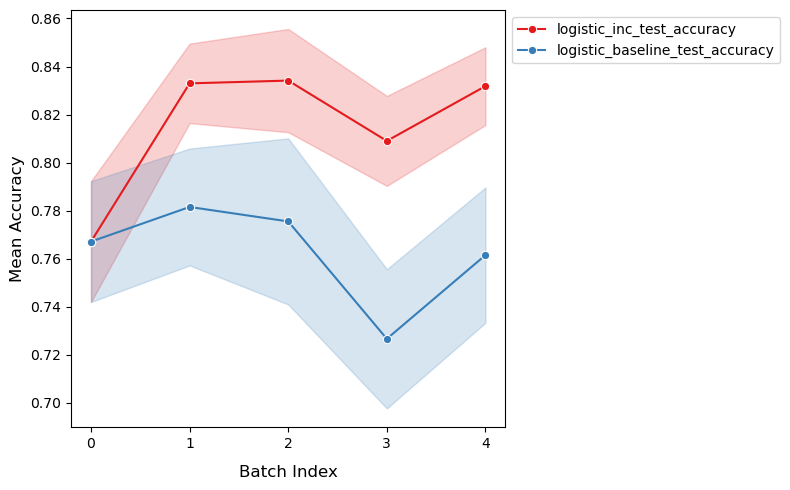

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_77080/1807757821.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


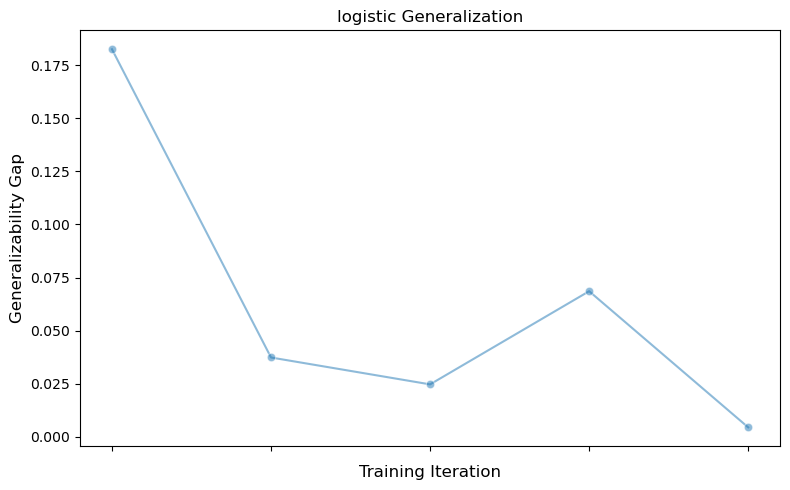

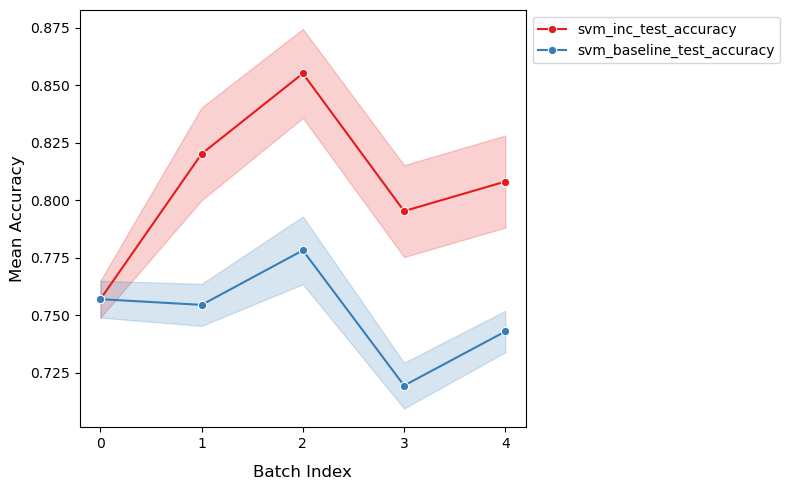

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_77080/1807757821.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


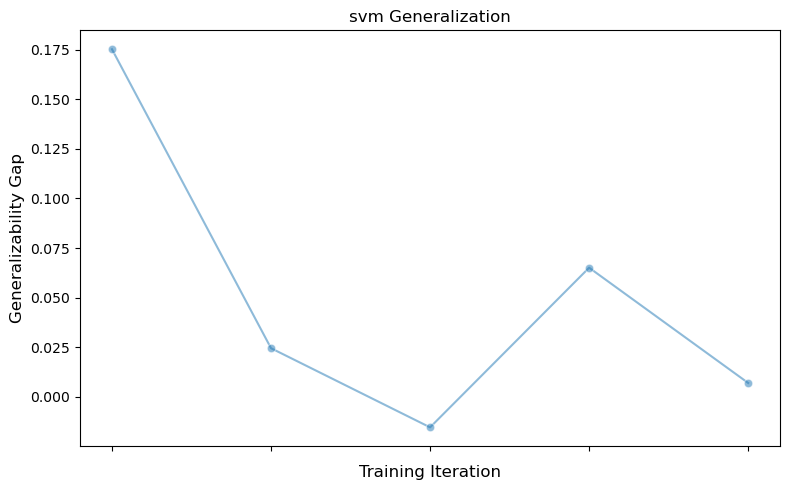

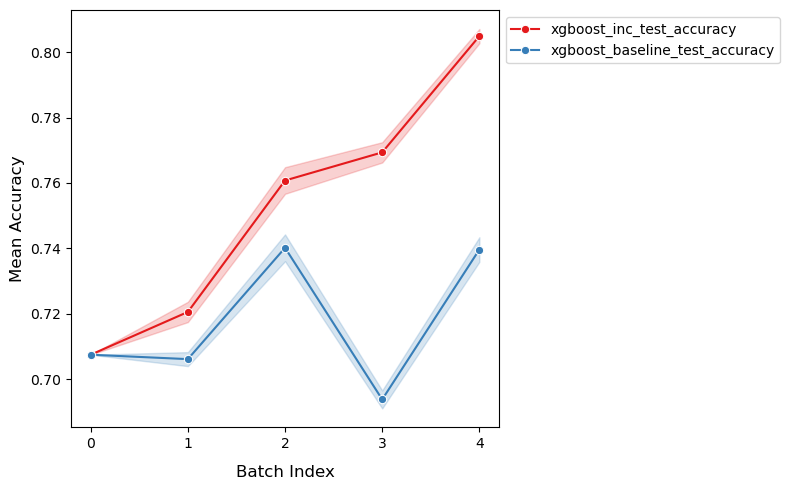

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_77080/1807757821.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


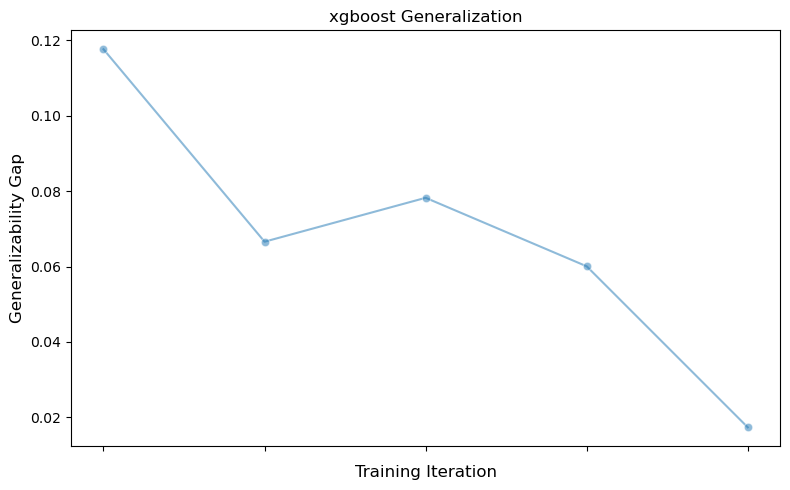

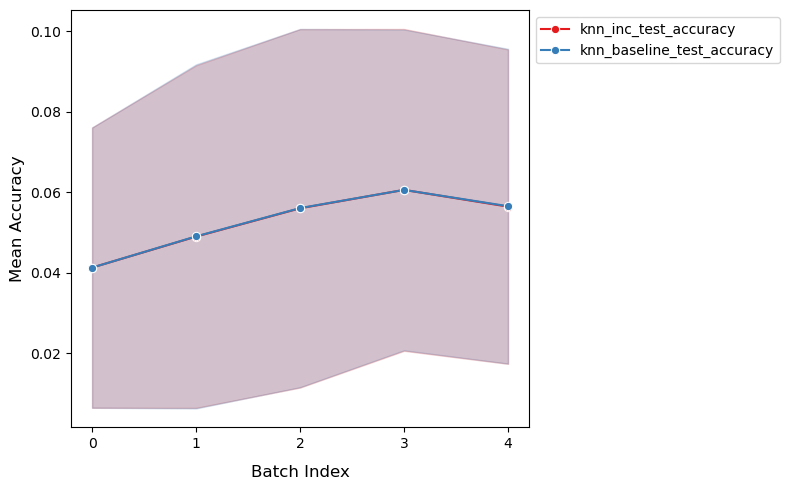

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_77080/1807757821.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


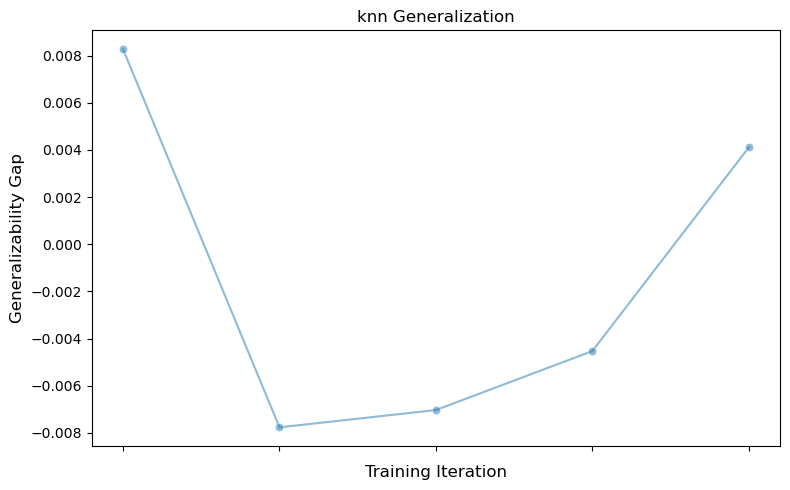

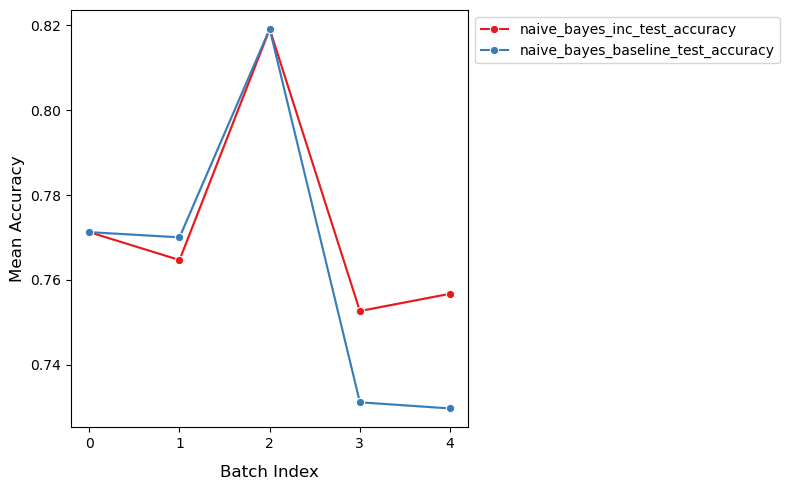

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_77080/1807757821.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


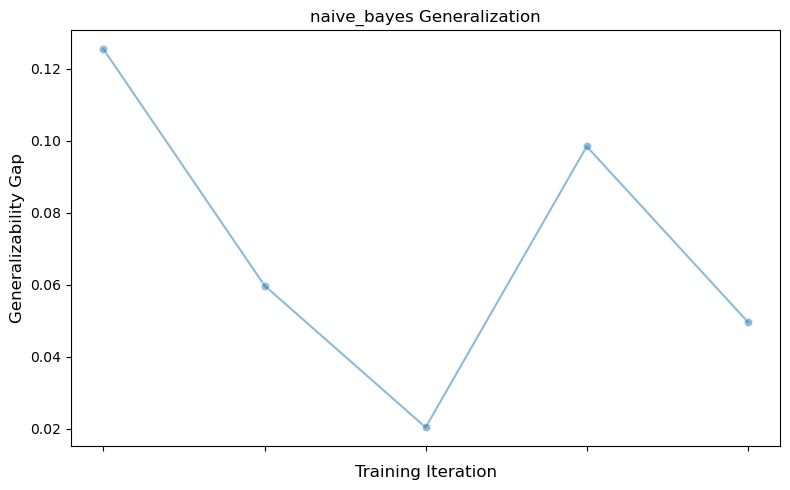

In [53]:
def overfitting_plt(model:str):
    compare = mean_model_scores[[f"{model}_inc_test_accuracy", f"{model}_baseline_test_accuracy"]]
    gen =mean_model_scores[f"{model}_inc_train_accuracy"] - mean_model_scores[f"{model}_inc_test_accuracy"]
# plot accuracy
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = sns.color_palette("Set1", n_colors=len(compare.columns))

    for i, col in enumerate(compare.columns):
        x = compare.index
        mean = compare[col]
        std = np.sqrt(var_model_scores[col])  # Standard deviation

        # Draw main line
        sns.lineplot(
            x=x,
            y=mean,
            label=col,
            color=colors[i],
            marker="o",
            ax=ax,
        )
        # Add shaded error band (mean ± std)
        ax.fill_between(x, mean - std, mean + std, color=colors[i], alpha=0.2)
        
    ax.set_xticks(compare.index)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.set_xlabel("Batch Index", size=12, labelpad=10)
    ax.set_ylabel("Mean Accuracy", size=12)

    plt.tight_layout()
    plt.show()

    # plot generalizability
    fig, ax = plt.subplots(figsize=(8, 5))  # slightly wider figure gives room
    sns.lineplot(
    data=gen,
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

# Move legend outside the plot area to the right
    # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.set_xticks(gen.index)
    ax.set_xlabel("Training Iteration", size=12, labelpad=10)
    ax.set_ylabel("Generalizability Gap", size=12)
    ax.tick_params(bottom=True, labelbottom=False)
    ax.set_title(f"{model} Generalization")

    plt.tight_layout()  # prevents legend text from getting clipped
    plt.show()

for clf in results.keys():
    overfitting_plt(clf)